# Supervised PCA with Bair's method

Bair's supervised PCA is a two-stage approach for regression. First, each feature is scored by how strongly it aligns with the target, and only features with score magnitude above a threshold `theta` are kept. Then standard PCA is run on this reduced feature set, and the top principal components are used as supervised predictors of the target.

In this notebook, we:
- load the Parkinsons telemonitoring dataset and apply the same centering/normalization as in `spca.ipynb`,
- sweep `theta` from `1.0` to `4.0` (step `0.1`) for `n_components=2`,
- plot training MSE across `theta` and select the best `theta`,
- refit with that best `theta` and visualize a 2D projection of 100 random samples, colored by target value.

In [13]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import torch
import matplotlib.pyplot as plt

from models.spca_bair import SPCA_Bair
from utils import load_parkinsons_data, normalize_to_minus1_1

### Data preparation

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load and preprocess data in the same style as spca.ipynb
X_t, y_t, feature_names = load_parkinsons_data(device)
X_t = X_t - X_t.mean(dim=0)
y_t = y_t - y_t.mean(dim=0)
X_t = normalize_to_minus1_1(X_t)
y_t = normalize_to_minus1_1(y_t)

# Convert to NumPy for SPCA_Bair
X = X_t.detach().cpu().numpy()
y = y_t.squeeze(-1).detach().cpu().numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 19)
y shape: (1000,)


### Hyperparameter tuning: theta in [1, 4] by optimizing MSE

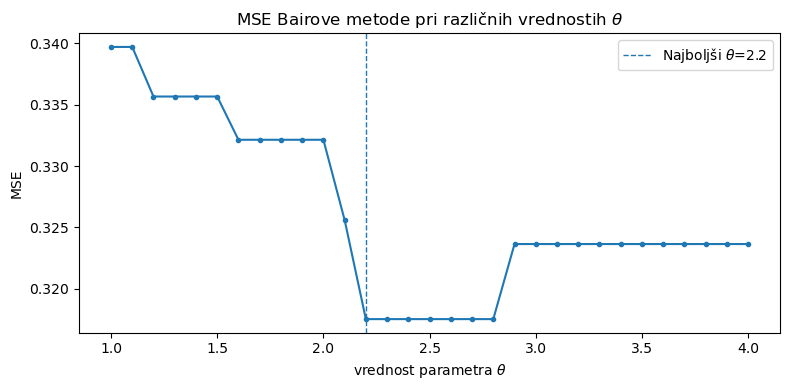

Best theta: 2.2
Best training MSE: 0.317518
Selected features at best theta: 5


In [15]:
theta_grid = np.round(np.arange(1.0, 4.0 + 1e-9, 0.1), 1)
results = []

for theta in theta_grid:
    model_t = SPCA_Bair(theta=float(theta), n_components=2)
    try:
        model_t.fit(X, y)
        mse_t = model_t.mse(X, y)
        results.append((theta, mse_t, len(model_t.selected_idx)))
    except ValueError:
        # Skip theta values that do not select enough features/components
        pass

if not results:
    raise RuntimeError("No valid theta found in the specified range.")

results = np.array(results, dtype=float)
valid_thetas = results[:, 0]
mses = results[:, 1]
selected_counts = results[:, 2].astype(int)

best_idx = np.argmin(mses)
best_theta = float(valid_thetas[best_idx])
best_mse = float(mses[best_idx])

plt.figure(figsize=(8, 4))
plt.plot(valid_thetas, mses, marker="o", markersize=3)
plt.axvline(best_theta, linestyle="--", linewidth=1, label=f"Najboljši $\\theta$={best_theta:.1f}")
plt.xlabel(f"vrednost parametra $\\theta$")
plt.ylabel("MSE")
plt.title(f"MSE Bairove metode pri različnih vrednostih $\\theta$")
plt.legend()
plt.tight_layout()
plt.savefig("../final_vizualizations/spca_bair_mse_theta.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/spca_bair_mse_theta.png", format="png", bbox_inches="tight")
plt.show()

print(f"Best theta: {best_theta:.1f}")
print(f"Best training MSE: {best_mse:.6f}")
print(f"Selected features at best theta: {selected_counts[best_idx]}")

### Visualization of the first two supervised principal components

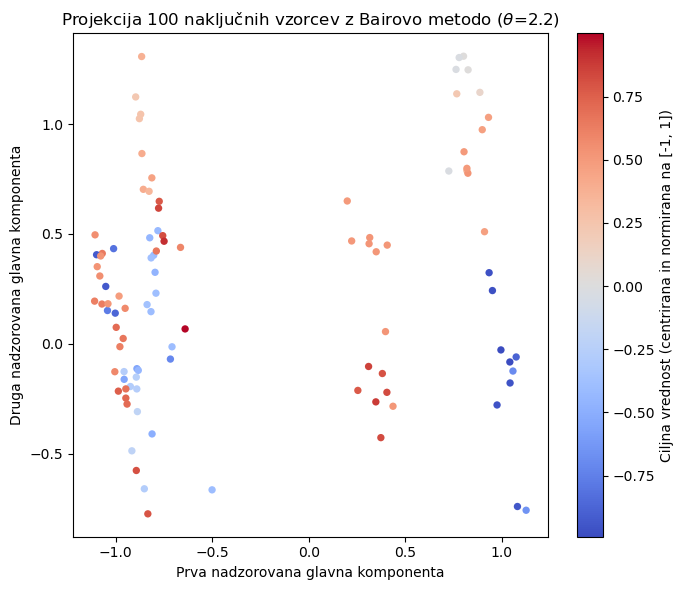

In [16]:
# Refit with best theta and create the same 2D visualization
model = SPCA_Bair(theta=best_theta, n_components=2)
model.fit(X, y)

rng = np.random.default_rng(0)
idx = rng.choice(X.shape[0], size=100, replace=False)

X_s = X[idx]
y_s = y[idx]

X_theta_s = X_s[:, model.selected_idx]
proj = X_theta_s @ model.w.T  # shape: (100, 2)

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    proj[:, 0],
    proj[:, 1],
    c=y_s,
    cmap="coolwarm",
    s=28,
    edgecolors="none",
)
plt.colorbar(sc, label="Ciljna vrednost (centrirana in normirana na [-1, 1])")
plt.xlabel("Prva nadzorovana glavna komponenta")
plt.ylabel("Druga nadzorovana glavna komponenta")
plt.title(f"Projekcija 100 naključnih vzorcev z Bairovo metodo ($\\theta$={best_theta:.1f})")
plt.tight_layout()
plt.savefig("../final_vizualizations/spca_bair_projection.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/spca_bair_projection.png", format="png", bbox_inches="tight")
plt.show()

The results show some potentially useful clusters for infering target values. However, even though some clusters are well separated on this visualization, the datapoints don't linearly progress in target value along any of the two principal components, which means that linear regression on them will not work very well.

### First two supervised principal component loadings

In [17]:
# Loadings of the first two Bair principal components
W = model.w  # shape: (2, n_selected_features)
selected_feature_names = [feature_names[i] for i in model.selected_idx]

for comp_idx in range(min(2, W.shape[0])):
    print(f"\nComponent {comp_idx + 1} loadings (sorted by absolute value):")
    order = np.argsort(np.abs(W[comp_idx]))[::-1]
    for rank, j in enumerate(order, start=1):
        sign = "+" if W[comp_idx, j] >= 0 else "-"
        print(f"  {rank:>2}. {sign}{abs(W[comp_idx, j]):.4f} * {selected_feature_names[j]}")


Component 1 loadings (sorted by absolute value):
   1. -0.9511 * age
   2. +0.2898 * DFA
   3. -0.0808 * RPDE
   4. +0.0519 * test_time
   5. +0.0469 * HNR

Component 2 loadings (sorted by absolute value):
   1. -0.7096 * DFA
   2. -0.4528 * RPDE
   3. -0.3613 * test_time
   4. +0.3586 * HNR
   5. -0.1798 * age
